# Stage 1 - Data Wrangling & EDA

First, import the required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

Load raw csv into dataframes and check data

In [2]:
credits_df = pd.read_csv('data/tmdb_5000_credits.csv')
movies_df = pd.read_csv('data/tmdb_5000_movies.csv')

credits_df.info()
movies_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   movie_id  4803 non-null   int64
 1   title     4803 non-null   str  
 2   cast      4803 non-null   str  
 3   crew      4803 non-null   str  
dtypes: int64(1), str(3)
memory usage: 150.2 KB
<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            48

Merge the two dataframes

In [3]:
merged_df = pd.merge(credits_df, movies_df, left_on='movie_id', right_on='id', how='inner')

# Delete unnecessary columns
merged_df.drop(columns=['title_y', 'movie_id'], inplace=True)
merged_df.rename(columns={'title_x': 'title'}, inplace=True)

merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 4803 non-null   str    
 1   cast                  4803 non-null   str    
 2   crew                  4803 non-null   str    
 3   budget                4803 non-null   int64  
 4   genres                4803 non-null   str    
 5   homepage              1712 non-null   str    
 6   id                    4803 non-null   int64  
 7   keywords              4803 non-null   str    
 8   original_language     4803 non-null   str    
 9   original_title        4803 non-null   str    
 10  overview              4800 non-null   str    
 11  popularity            4803 non-null   float64
 12  production_companies  4803 non-null   str    
 13  production_countries  4803 non-null   str    
 14  release_date          4802 non-null   str    
 15  revenue               4803 non-n

Let's see what the data looks like

In [4]:
merged_df.head(5)

,title,cast,crew,budget,genres,homepage,id,keywords,original_language,original_title,...,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,vote_average,vote_count
0,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,...,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,7.2,11800
1,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,...,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",6.9,4500
2,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,...,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,6.3,4466
3,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,...,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,7.6,9106
4,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,...,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",6.1,2124


Identify which columns need to be parsed

In [5]:
columns_to_parse = []
for col in merged_df.select_dtypes(include='str').columns:
    if merged_df[col].dropna().iloc[0].strip().startswith(('[', '{')):
        columns_to_parse.append(col)

print(columns_to_parse)

['cast', 'crew', 'genres', 'keywords', 'production_companies', 'production_countries', 'spoken_languages']


Convert JSON data into Python lists

In [6]:
def parse_names(column):
    if pd.isna(column):
        return []
    try:
        return [entry['name'] for entry in ast.literal_eval(column)]
    except (ValueError, SyntaxError):
        return []

for column in columns_to_parse:
    merged_df[column] = merged_df[column].apply(parse_names)

merged_df.head(5)

,title,cast,crew,budget,genres,homepage,id,keywords,original_language,original_title,...,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,vote_average,vote_count
0,Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weave...","[Stephen E. Rivkin, Rick Carter, Christopher B...",237000000,"[Action, Adventure, Fantasy, Science Fiction]",http://www.avatarmovie.com/,19995,"[culture clash, future, space war, space colon...",en,Avatar,...,"[Ingenious Film Partners, Twentieth Century Fo...","[United States of America, United Kingdom]",2009-12-10,2787965087,162.0,"[English, Español]",Released,Enter the World of Pandora.,7.2,11800
1,Pirates of the Caribbean: At World's End,"[Johnny Depp, Orlando Bloom, Keira Knightley, ...","[Dariusz Wolski, Gore Verbinski, Jerry Bruckhe...",300000000,"[Adventure, Fantasy, Action]",http://disney.go.com/disneypictures/pirates/,285,"[ocean, drug abuse, exotic island, east india ...",en,Pirates of the Caribbean: At World's End,...,"[Walt Disney Pictures, Jerry Bruckheimer Films...",[United States of America],2007-05-19,961000000,169.0,[English],Released,"At the end of the world, the adventure begins.",6.9,4500
2,Spectre,"[Daniel Craig, Christoph Waltz, Léa Seydoux, R...","[Thomas Newman, Sam Mendes, Anna Pinnock, John...",245000000,"[Action, Adventure, Crime]",http://www.sonypictures.com/movies/spectre/,206647,"[spy, based on novel, secret agent, sequel, mi...",en,Spectre,...,"[Columbia Pictures, Danjaq, B24]","[United Kingdom, United States of America]",2015-10-26,880674609,148.0,"[Français, English, Español, Italiano, Deutsch]",Released,A Plan No One Escapes,6.3,4466
3,The Dark Knight Rises,"[Christian Bale, Michael Caine, Gary Oldman, A...","[Hans Zimmer, Charles Roven, Christopher Nolan...",250000000,"[Action, Crime, Drama, Thriller]",http://www.thedarkknightrises.com/,49026,"[dc comics, crime fighter, terrorist, secret i...",en,The Dark Knight Rises,...,"[Legendary Pictures, Warner Bros., DC Entertai...",[United States of America],2012-07-16,1084939099,165.0,[English],Released,The Legend Ends,7.6,9106
4,John Carter,"[Taylor Kitsch, Lynn Collins, Samantha Morton,...","[Andrew Stanton, Andrew Stanton, John Lasseter...",260000000,"[Action, Adventure, Science Fiction]",http://movies.disney.com/john-carter,49529,"[based on novel, mars, medallion, space travel...",en,John Carter,...,[Walt Disney Pictures],[United States of America],2012-03-07,284139100,132.0,[English],Released,"Lost in our world, found in another.",6.1,2124


Check for missing data

In [7]:
merged_df.isnull().sum()

title                      0
cast                       0
crew                       0
budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
vote_average               0
vote_count                 0
dtype: int64

In [8]:
merged_df['homepage'] = merged_df['homepage'].fillna('')
merged_df['tagline'] = merged_df['tagline'].fillna('')
merged_df['overview'] = merged_df['overview'].fillna('')
merged_df.dropna(inplace=True)

merged_df.info()

<class 'pandas.DataFrame'>
Index: 4800 entries, 0 to 4802
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 4800 non-null   str    
 1   cast                  4800 non-null   object 
 2   crew                  4800 non-null   object 
 3   budget                4800 non-null   int64  
 4   genres                4800 non-null   object 
 5   homepage              4800 non-null   str    
 6   id                    4800 non-null   int64  
 7   keywords              4800 non-null   object 
 8   original_language     4800 non-null   str    
 9   original_title        4800 non-null   str    
 10  overview              4800 non-null   str    
 11  popularity            4800 non-null   float64
 12  production_companies  4800 non-null   object 
 13  production_countries  4800 non-null   object 
 14  release_date          4800 non-null   str    
 15  revenue               4800 non-null  

Engineer the data to correct format

In [9]:
merged_df['profit'] = merged_df['revenue'] - merged_df['budget']
merged_df['profit'].head(5)

0    2550965087
1     661000000
2     635674609
3     834939099
4      24139100
Name: profit, dtype: int64

In [10]:
merged_df['release_date'] = pd.to_datetime(merged_df['release_date'], errors='coerce')
merged_df['release_year'] = merged_df['release_date'].dt.year
merged_df['release_year'].head(5)

0    2009
1    2007
2    2015
3    2012
4    2012
Name: release_year, dtype: int32

In [11]:
merged_df['cast_size'] = merged_df['cast'].apply(len)
merged_df['cast_size'].head(5)

0     83
1     34
2     83
3    158
4     27
Name: cast_size, dtype: int64

Visualize the data

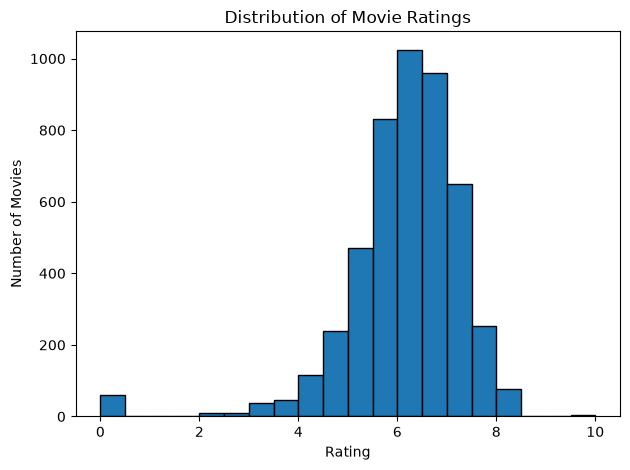

In [12]:
# Histogram of ratings
plt.hist(merged_df['vote_average'], bins=20, edgecolor='black')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('images/rating_distribution.png', bbox_inches='tight')
plt.show()

This plot shows the distribution of movie ratings. Here we can see that the rating with the highest prevalence is 6. We also see that the ratings generally lie between a 4 and an 8 with only a few outliers at 0 and 10.

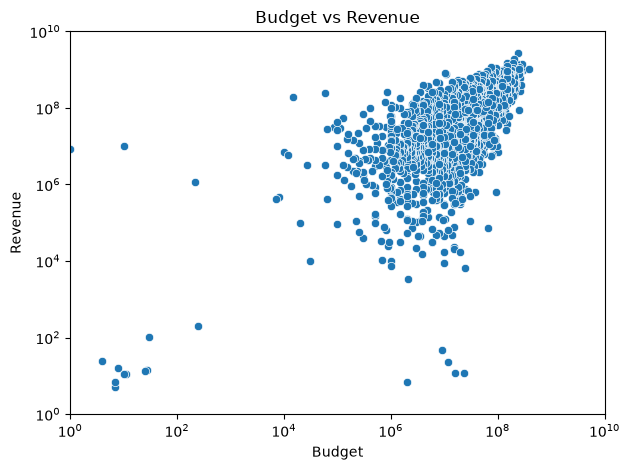

In [13]:
# Scatterplot of budget vs revenue
plt.title('Budget vs Revenue')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1,1e10)
plt.ylim(1,1e10)
plt.tight_layout()
sns.scatterplot(data=merged_df, x='budget', y='revenue')
plt.savefig('images/budget_vs_revenue.png', bbox_inches='tight')

The scatterplot of budget vs revenue shows that most movies tend to make back about how much they spend. There is a pretty large disparity in some of these numbers however where we can see some movies make much less than what they spent, and some make much more.

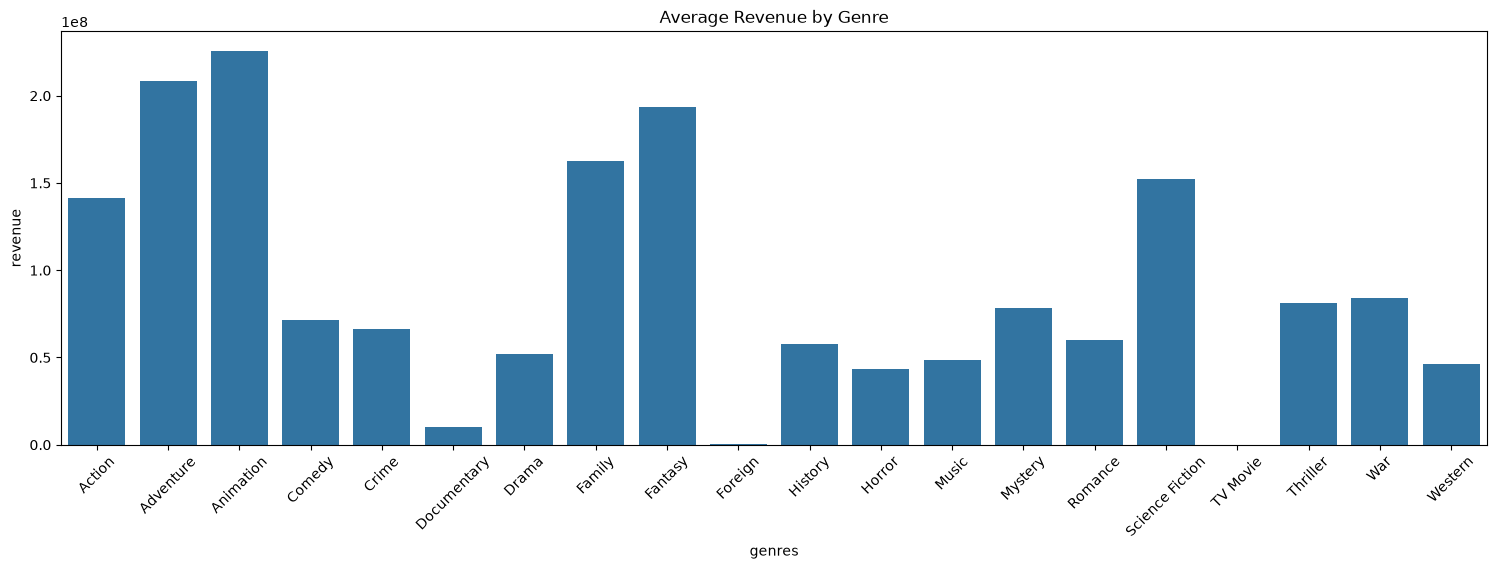

In [14]:
# Bar chart of average revenue by genre
avg_revenue_by_genre = merged_df.explode('genres').groupby('genres')['revenue'].mean()
plt.figure(figsize=(15,5))
plt.xticks(rotation=45)
plt.tight_layout()
plt.title('Average Revenue by Genre')
plt.tight_layout()
sns.barplot(data=avg_revenue_by_genre.to_frame(), x='genres', y='revenue')
plt.savefig('images/revenue_by_genre.png', bbox_inches='tight')

This bar plot represents the average revenue from each genre of movie. The most revenue generating genre is Animation, followed by Adventure and Fantasy. Foreign movies and Documentaries generate a significantly less amount of revenue

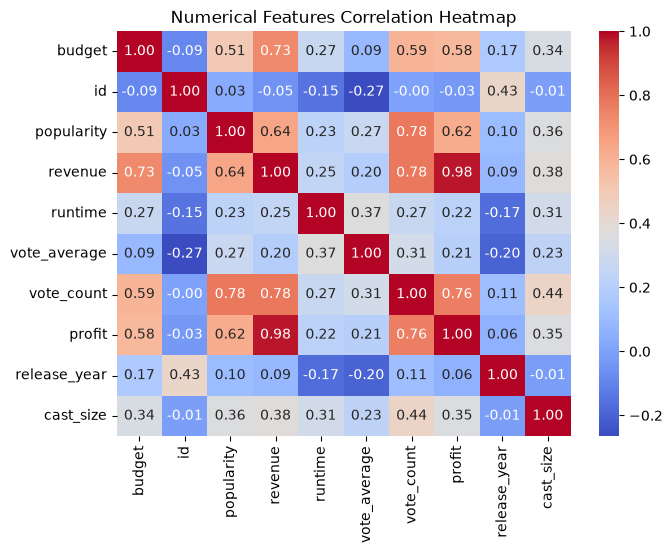

In [15]:
# Correlation heatmap of numerical featuresplt.tight_layout()
plt.title('Numerical Features Correlation Heatmap')
plt.tight_layout()
sns.heatmap(merged_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.savefig('images/correlation_heatmap.png', bbox_inches='tight')

The heatmap shows correlations between each numerical feature in the dataframe. The largest correlation is between profit an revenue. This is obvious because the equation for profit is revenue - budget. Other medium-strong correlations include popularity and vote count, revenue and vote count, popularity and revenue, and profit and vote count, among a few others

Export dataframe to a csv

In [16]:
merged_df.to_csv('data/movies_clean.csv')